In [2]:
import pandas as pd
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [3]:
mat = scipy.io.loadmat('Xtrain.mat')

In [4]:
df = pd.DataFrame(mat['Xtrain'])

In [5]:
df.head()

,0
0,86
1,141
2,95
3,41
4,22


In [6]:
# scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_data

array([[ 5.57201545e-01],
       [ 1.73111118e+00],
       [ 7.49295849e-01],
       [-4.03269976e-01],
       [-8.08802396e-01],
       [-8.30146207e-01],
       [-5.95364280e-01],
       [ 2.58388183e-01],
       [ 1.66707975e+00],
       [ 1.09079683e+00],
       [-2.53863295e-01],
       [-7.87458584e-01],
       [-8.72833830e-01],
       [-7.02083338e-01],
       [-1.90813675e-02],
       [ 1.47498544e+00],
       [ 1.47498544e+00],
       [-4.04251791e-02],
       [-7.02083338e-01],
       [-8.72833830e-01],
       [-7.66114772e-01],
       [-2.96550918e-01],
       [ 1.11214065e+00],
       [ 1.79514262e+00],
       [ 2.79731994e-01],
       [-6.38051903e-01],
       [-8.51490019e-01],
       [-8.72833830e-01],
       [-4.88645222e-01],
       [ 6.85264414e-01],
       [ 1.96589311e+00],
       [ 7.06608226e-01],
       [-5.09989034e-01],
       [-8.51490019e-01],
       [-8.94177642e-01],
       [-6.59395715e-01],
       [ 2.37044371e-01],
       [ 1.83783024e+00],
       [ 1.2

# Plot

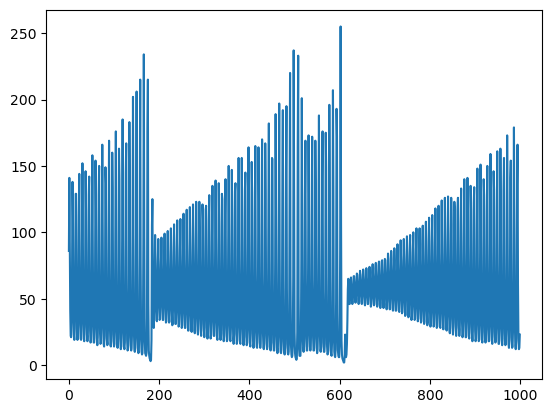

In [7]:
Y = df.values
X = range(len(Y))

plt.plot(X, Y)

# Model

In [8]:
# from prophet import Prophet

In [9]:
# # Prepare data for Prophet
# prophet_df = pd.DataFrame({
#     'ds': pd.date_range(start='2025-01-01', periods=len(df), freq='D'),
#     'y': df.values.flatten()
# })

# # Fit Prophet with seasonality disabled
# m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True)
# m.fit(prophet_df)

# # Forecast next 50 steps
# future = m.make_future_dataframe(periods=50)
# forecast = m.predict(future)
# forecast

In [10]:
# # Plot original data and forecast
# plt.figure(figsize=(12, 6))

# # Original data
# plt.plot(range(len(df)), df.values.flatten(), label='Original Data', color='blue')

# # Forecast (including historical fit)
# forecast_values = forecast['yhat'].values
# plt.plot(range(len(forecast_values)), forecast_values, label='Prophet Forecast', color='red', linestyle='--')

# # Highlight future predictions
# future_preds = forecast.tail(5)['yhat'].values
# plt.plot(range(len(df), len(df) + 5), future_preds, label='Future Predictions (200 steps)', color='green', marker='o')

# plt.xlabel('Time Step')
# plt.ylabel('Value')
# plt.title('Prophet Forecast vs Original Data')
# plt.legend()
# plt.grid(True)
# plt.show()

In [15]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Fit ARIMA model
# (p, d, q) = (autoregressive order, differencing order, moving average order)
arima_model = ARIMA(df.values.flatten(), order=(50, 1, 0))
arima_fit = arima_model.fit()

print(arima_fit.summary())

c:\Users\matth\anaconda3\envs\DL\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                ARIMA(50, 1, 0)   Log Likelihood               -4446.896
Date:                Wed, 29 Apr 2026   AIC                           8995.793
Time:                        12:29:09   BIC                           9246.037
Sample:                             0   HQIC                          9090.908
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4436      0.020    -21.776      0.000      -0.484      -0.404
ar.L2         -1.0355      0.027    -38.978      0.000      -1.088      -0.983
ar.L3         -0.8621      0.038    -22.698      0.0

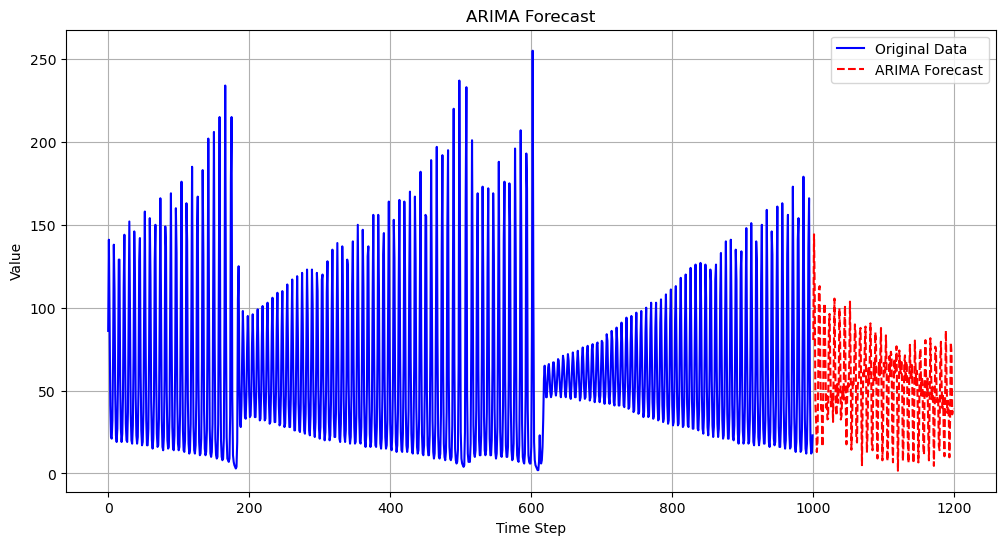

In-sample RMSE: 20.6544


In [17]:
# Forecast next 50 steps
forecast_steps = 200
arima_forecast = arima_fit.forecast(steps=forecast_steps)

# Plot original data and ARIMA forecast
plt.figure(figsize=(12, 6))
plt.plot(range(len(df)), df.values.flatten(), label='Original Data', color='blue')
plt.plot(range(len(df), len(df) + forecast_steps), arima_forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.title('ARIMA Forecast')
plt.legend()
plt.grid(True)
plt.show()

# Calculate RMSE on training data (in-sample)
train_pred = arima_fit.fittedvalues
rmse = np.sqrt(mean_squared_error(df.values.flatten()[1:], train_pred[1:]))
print(f"In-sample RMSE: {rmse:.4f}")